In [ ]:
"""
Importing zip file and extracting the dataset here.
"""
import zipfile, os

zip_path = '/content/Financial Phrase Dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('/content/financial_data')

for root, dirs, files in os.walk('/content/financial_data'):
    for f in files:
        print(os.path.join(root, f))

/content/financial_data/3. Financial Phrase Dataset/financial_phrase.csv
/content/financial_data/3. Financial Phrase Dataset/3. Description Financial Phrase Dataset.txt


In [ ]:
!pip install nltk --quiet
!pip install wordcloud --quiet

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
!pip install gensim --quiet
import gensim
print(gensim.__version__)


4.4.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gensim.downloader as api

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight # Imports a tool that calculates how much importance to give each class during training.
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer #a tool that converts raw text into numbers.

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

In [ ]:
import pandas as pd
import numpy as np
import re #lets you search for and remove specific patterns in text
import matplotlib.pyplot as plt
from nltk.corpus import stopwords # Imports a list of stopwords from NLTK
from nltk.stem import WordNetLemmatizer #a tool that reduces words to their root form
from wordcloud import WordCloud

df = pd.read_csv('/content/financial_data/3. Financial Phrase Dataset/financial_phrase.csv',
                 encoding='latin-1')

print("Shape before cleaning:", df.shape)
print(df['label'].value_counts())

Shape before cleaning: (2264, 2)
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64


In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [ ]:
"""
Raw text is full of noise that distracts the model punctuation, numbers, common words, different word forms.
If I feed 'loss', 'losses' and 'losing' as three separate words, the model treats them as unrelated
"""
def clean_text(text): #It takes a raw messy sentence and returns a clean, stripped-down version.
    text = text.lower()

    contractions = {
        "don't": "do not",
        "can't": "cannot",
        "won't": "will not",
        "it's": "it is",
        "i'm": "i am"
    }

    for k, v in contractions.items():
        text = text.replace(k, v)

    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(w)
        for w in tokens
        if w not in stop_words and len(w) > 1
    ]

    return ' '.join(tokens)

In [ ]:
df['cleaned'] = df['text'].apply(clean_text)

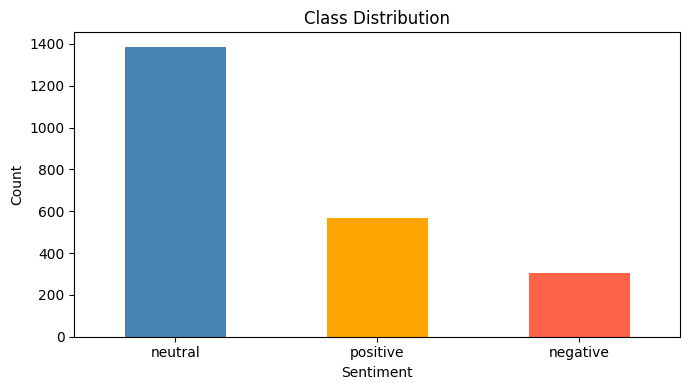

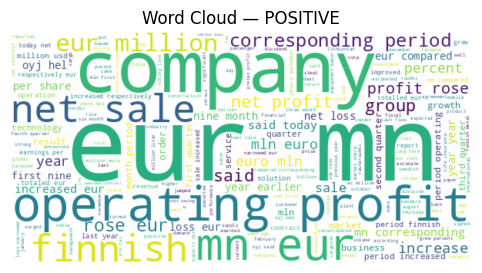

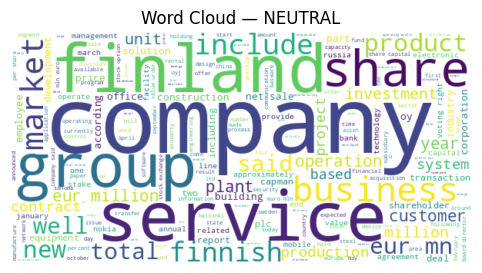

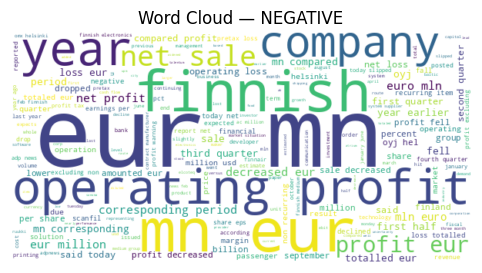

In [ ]:
"""
It visually explores the financial dataset in two ways a bar chart revealing the class imbalance between positive,
neutral and negative phrases and three word clouds showing which words dominate each sentiment category.
"""
plt.figure(figsize=(7,4))
df['label'].value_counts().plot(kind='bar', color=['steelblue','orange','tomato'])
plt.title('Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

for label in ['positive', 'neutral', 'negative']:
    text = ' '.join(df[df['label']==label]['cleaned'])
    wc = WordCloud(width=600, height=300, background_color='white').generate(text)
    plt.figure(figsize=(8,3))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud — {label.upper()}')
    plt.show()

In [ ]:
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(df['label'])

NUM_CLASSES = len(le.classes_)
y_cat = to_categorical(y_encoded, num_classes=NUM_CLASSES)

In [ ]:
X = df['cleaned'].values
y = y_cat

# Splits ALL data into 80% training and 20% test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_encoded
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

MAX_WORDS = 5000

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

train_seq = tokenizer.texts_to_sequences(X_train)
MAX_LEN = int(np.percentile([len(x) for x in train_seq], 95))

def pad(texts):
    return pad_sequences(tokenizer.texts_to_sequences(texts),
                         maxlen=MAX_LEN,
                         padding='post')

X_train_pad = pad(X_train)
X_val_pad = pad(X_val)
X_test_pad = pad(X_test)

In [ ]:
y_train_labels = np.argmax(y_train, axis=1) #Converts one-hot encoded labels back into plain number labels.

classes = np.unique(y_train_labels)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_labels
)

class_weight_dict = {i: w for i, w in zip(classes, class_weights)}

In [ ]:
VOCAB_SIZE = MAX_WORDS
EMBED_DIM = 64

rnn_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM),
    SimpleRNN(64),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

rnn_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

lstm_model.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

In [ ]:
EMBED_DIM = 300 # Google's pre-trained Word2Vec uses 300-dimensional vectors

w2v = api.load('word2vec-google-news-300')

word_index = tokenizer.word_index
embedding_matrix = np.zeros((MAX_WORDS, EMBED_DIM))

for word, i in word_index.items():
    if i < MAX_WORDS and word in w2v:
        embedding_matrix[i] = w2v[word]

In [ ]:
lstm_word2vec = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBED_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False
    ),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

lstm_word2vec.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
hist_rnn = rnn_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[es]
)

hist_lstm = lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[es]
)

hist_word2vec = lstm_word2vec.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[es]
)

Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.4505 - loss: 1.0606 - val_accuracy: 0.7044 - val_loss: 0.7232
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7343 - loss: 0.7469 - val_accuracy: 0.7541 - val_loss: 0.5746
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8630 - loss: 0.5001 - val_accuracy: 0.7182 - val_loss: 0.6531
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9294 - loss: 0.2911 - val_accuracy: 0.7597 - val_loss: 0.6828
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9585 - loss: 0.1818 - val_accuracy: 0.7459 - val_loss: 0.8642
Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.5619 - loss: 1.0723 - val_accuracy: 0.6685 - val_loss: 0.7590
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7308 - loss: 0.8190 - val_accuracy: 0.6823 - val_loss: 0.8527
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7730 - loss: 0.6536 - val_accuracy: 0.6298 - v

In [ ]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = np.argmax(model.predict(X_test), axis=1)
    y_true = np.argmax(y_test, axis=1)

    print("\n", "="*40)
    print(name)
    print("="*40)

    print(classification_report(y_true, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step

Simple RNN
              precision    recall  f1-score   support

    negative       0.37      0.31      0.34        61
     neutral       0.89      0.88      0.89       277
    positive       0.57      0.64      0.61       114

    accuracy                           0.74       452
   macro avg       0.61      0.61      0.61       452
weighted avg       0.74      0.74      0.74       452



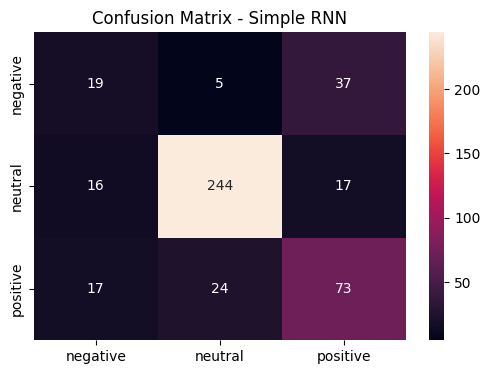

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step

LSTM
              precision    recall  f1-score   support

    negative       0.32      0.75      0.45        61
     neutral       0.89      0.90      0.90       277
    positive       0.54      0.13      0.21       114

    accuracy                           0.69       452
   macro avg       0.58      0.60      0.52       452
weighted avg       0.72      0.69      0.66       452



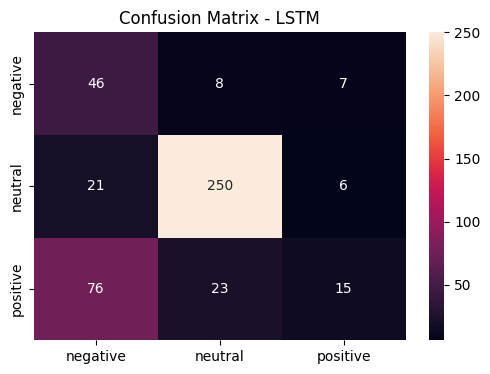

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step

LSTM + Word2Vec
              precision    recall  f1-score   support

    negative       0.40      0.51      0.45        61
     neutral       0.92      0.87      0.90       277
    positive       0.46      0.46      0.46       114

    accuracy                           0.72       452
   macro avg       0.60      0.61      0.60       452
weighted avg       0.74      0.72      0.73       452



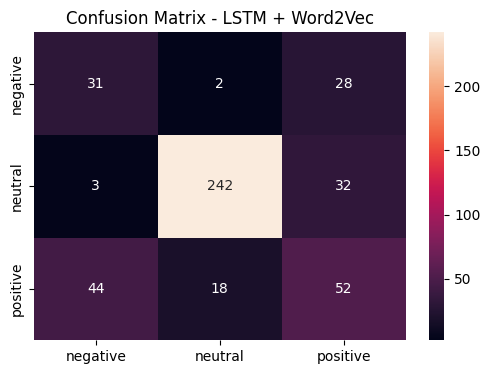

In [ ]:
evaluate_model(rnn_model, X_test_pad, y_test, "Simple RNN")
evaluate_model(lstm_model, X_test_pad, y_test, "LSTM")
evaluate_model(lstm_word2vec, X_test_pad, y_test, "LSTM + Word2Vec")

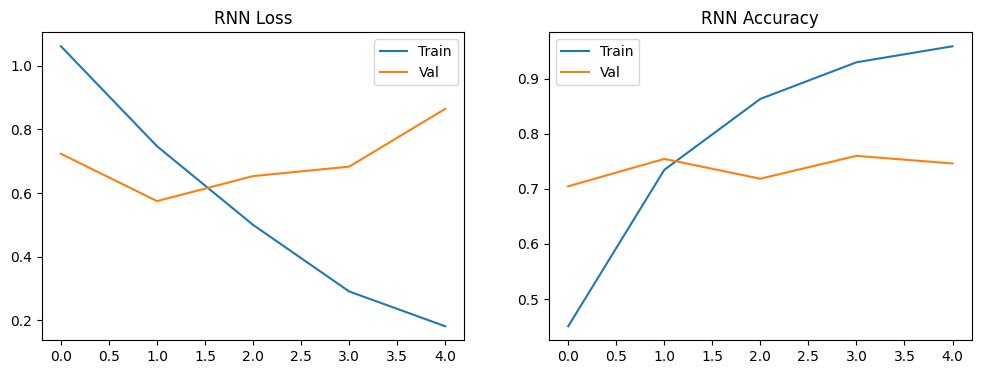

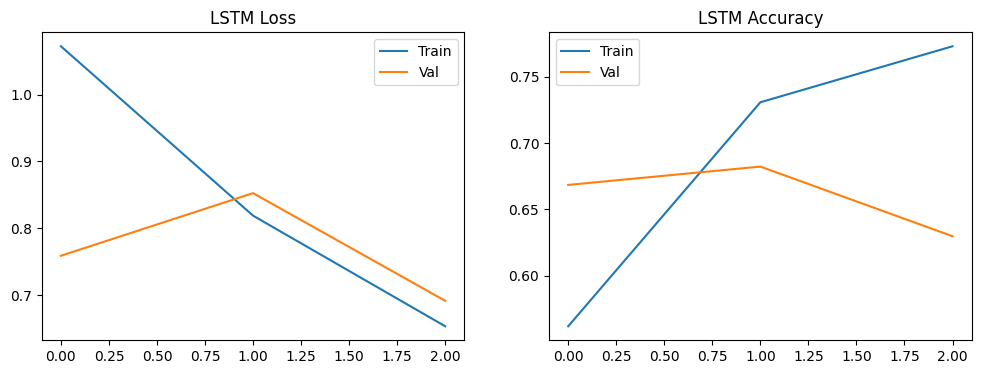

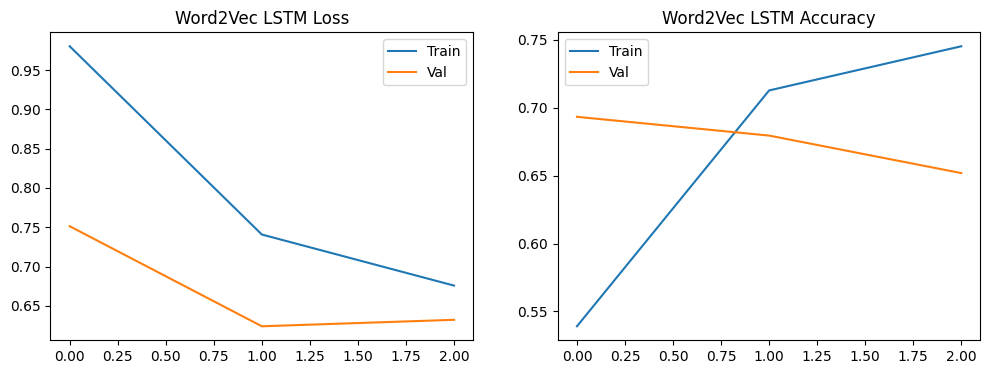

In [ ]:
def plot_history(hist, name):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(hist.history['loss'], label='Train')
    plt.plot(hist.history['val_loss'], label='Val')
    plt.title(name + " Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(hist.history['accuracy'], label='Train')
    plt.plot(hist.history['val_accuracy'], label='Val')
    plt.title(name + " Accuracy")
    plt.legend()

    plt.show()

plot_history(hist_rnn, "RNN")
plot_history(hist_lstm, "LSTM")
plot_history(hist_word2vec, "Word2Vec LSTM")

In [ ]:
y_pred_labels = np.argmax(lstm_word2vec.predict(X_test_pad), axis=1)
y_true_labels = np.argmax(y_test, axis=1)

misclassified = np.where(y_pred_labels != y_true_labels)[0]

print("Misclassified:", len(misclassified))

for i in misclassified[:3]:
    print("Text:", X_test[i])
    print("True:", le.classes_[y_true_labels[i]])
    print("Pred:", le.classes_[y_pred_labels[i]])
    print("-"*50)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Misclassified: 127
Text: finnish metal product company componenta oyj net profit rose mln euro mln first quarter mln euro mln period
True: positive
Pred: negative
--------------------------------------------------
Text: operating profit kauppalehti group rose eur mn eur mn marketplace eur mn eur mn third quarter
True: positive
Pred: negative
--------------------------------------------------
Text: fourth quarter oko bank expects operating environment banking investment service remain similar january september
True: neutral
Pred: positive
--------------------------------------------------


In [ ]:
!pip install gradio

import gradio as gr

def predict_sentiment(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=50, padding='post')
    pred = lstm_glove.predict(padded)
    classes = ['Negative', 'Neutral', 'Positive']
    return classes[pred.argmax()]

demo = gr.Interface(fn=predict_sentiment, inputs="text", outputs="text",
                    title="Financial Sentiment Predictor")
demo.launch()